In [1]:
library(numbat)
library(dplyr)
library(Seurat)
library(data.table)
library(future)
plan("multicore", workers = 12)
options(future.globals.maxSize = 10000 * 1024^10,
        future.rng.onMisuse = 'ignore')
sessionInfo()

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




R version 4.2.3 (2023-03-15)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 8.7 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_python/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] future_1.32.0           data.table_1.14.8       Seurat_4.9.9.9040      
[4] SeuratObject_4.9.9.9081 sp_1.6-0                dplyr_1.1.1            
[7] numbat_1.2.3            Matrix_1.5-3           

loaded via a namespace (and not attached):
  [1] uuid_1.1-0             spam_

In [2]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/merged_dmg_atlas_qc_filtered.rds')
dmg

An object of class Seurat 
38576 features across 409561 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

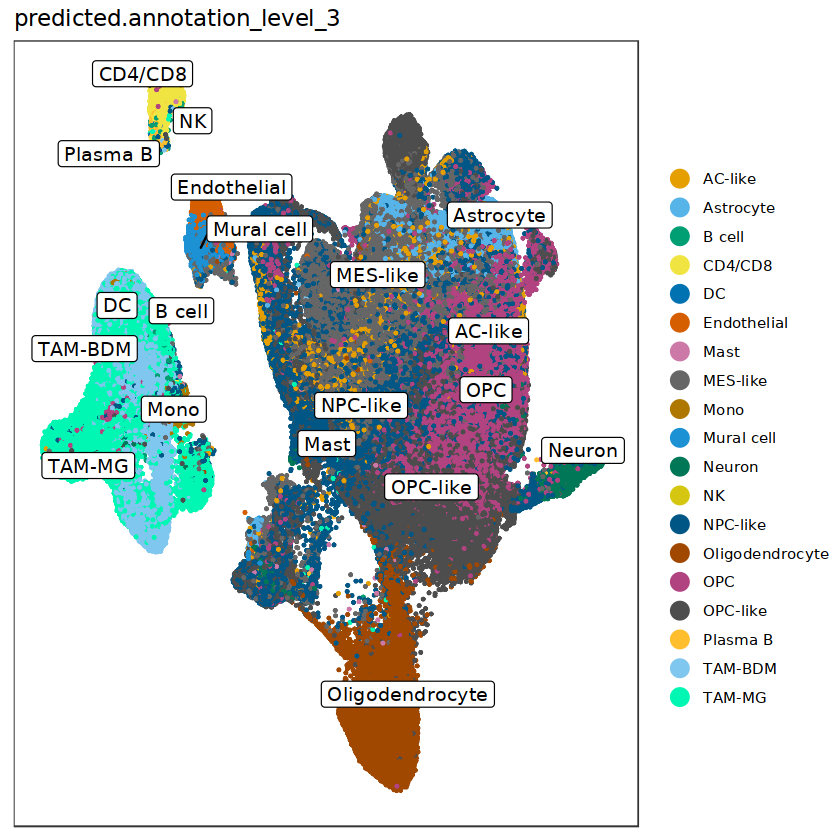

In [3]:
dittoSeq::dittoDimPlot(dmg, 
             reduction.use = "umap", var = "predicted.annotation_level_3", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [4]:
dmg$numbat_id <- recode(dmg$predicted.annotation_level_3,
                         `AC-like` = 'Malignant',
                                       `MES-like` = "Malignant",    
                                       `OPC-like` = "Malignant", 
                                       `NPC-like` = "Malignant",    
                                       `Astrocyte` = "Glial_Neuronal", 
                                       # `Oligodendrocyte` = "Glial_Neuronal",    
                                       `OPC` = "Glial_Neuronal", 
                                       `Neuron` = "Glial_Neuronal",
                                        `Mono` = "Myeloid",
                                       `TAM-BDM` = "Myeloid",    
                                       `TAM-MG` = "Myeloid", 
                                       `DC` = "Myeloid",    
                                       `Mast` = "Myeloid",
                                       `CD4/CD8` = "Lymphoid",    
                                       `NK` = "Lymphoid", 
                                       `B cell` = "Lymphoid",    
                                       `Plasma B` = "Lymphoid",
                                       `Endothelial` = "Vascular",    
                                       `Mural cell` = "Vascular"
                         )
Idents(dmg) <- dmg$numbat_id
table(dmg@active.ident)


      Malignant  Glial_Neuronal        Vascular         Myeloid Oligodendrocyte 
         231886           78710            7188           60905           25955 
       Lymphoid 
           4917 

In [5]:
`%nin%` <- function(x, y) !(x %in% y)
dmg <- subset(dmg, Study %nin% c('Filbin2018', 'Liu2022'))
dmg
gc()

An object of class Seurat 
38576 features across 397794 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8382606,447.7,16414108,876.7,16414108,876.7
Vcells,12653726388,96540.3,16213889217,123702.2,12897181282,98397.7


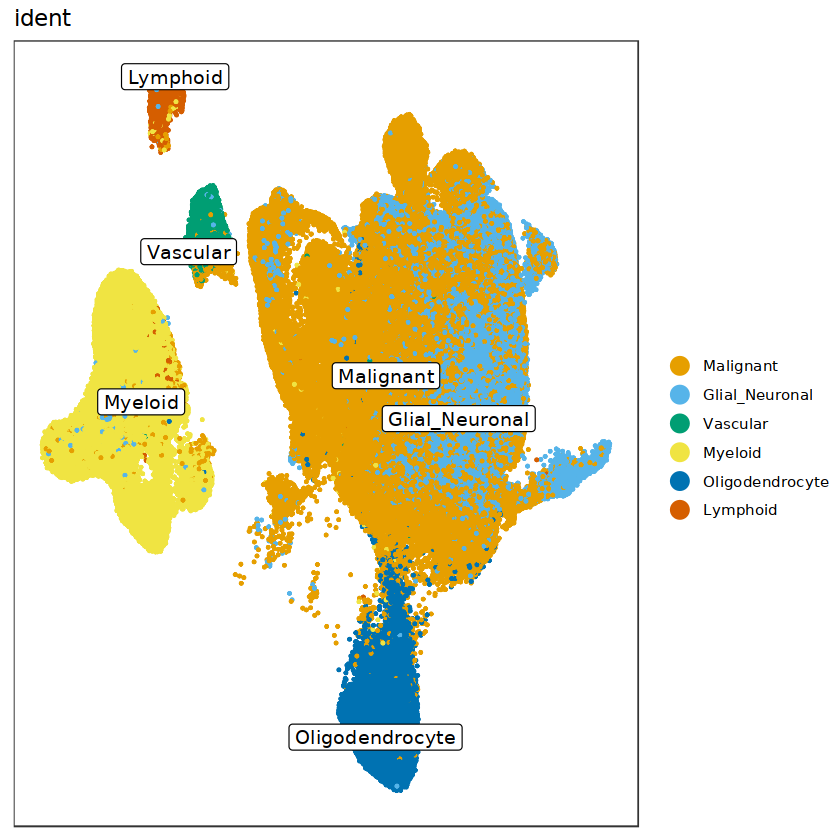

In [6]:
dittoSeq::dittoDimPlot(dmg, 
             reduction.use = "umap", var = 'ident', 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

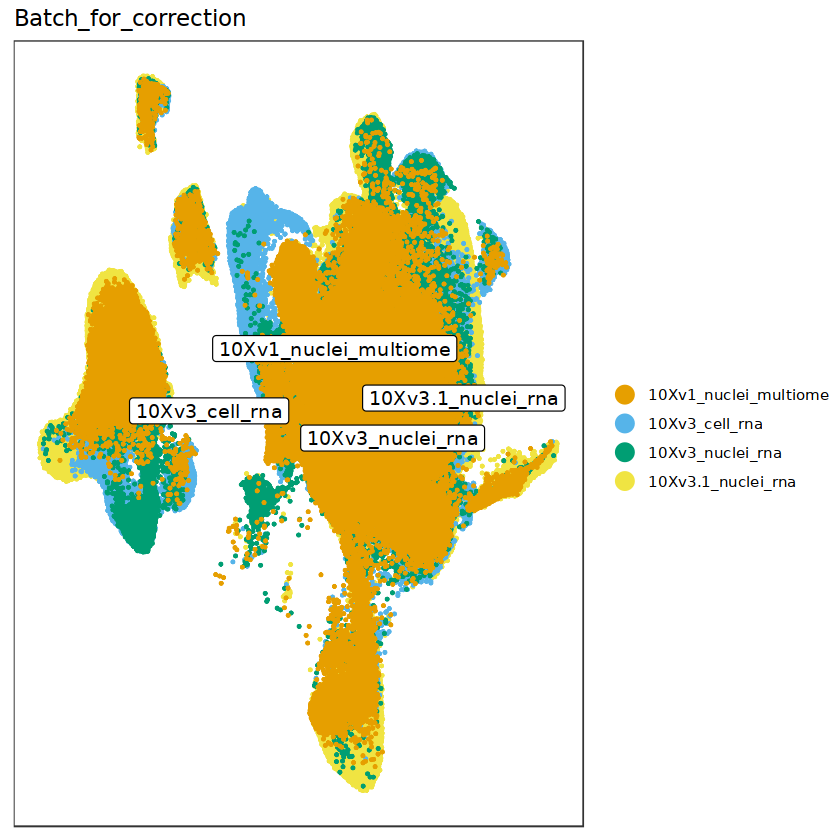

In [7]:
dittoSeq::dittoDimPlot(dmg, 
             reduction.use = "umap", var = 'Batch_for_correction', 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [8]:
dmg <- subset(dmg, Batch_for_correction == '10Xv3_nuclei_rna')
dmg

An object of class Seurat 
38576 features across 54529 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [9]:
ref_internal = aggregate_counts(GetAssayData(subset(dmg, 
                                                   idents = c('Malignant', 'Glial_Neuronal'),
                                                   invert = TRUE),
                                             slot = 'counts'
                                            ), 
                               as.data.frame(dmg@active.ident) %>% 
                                `colnames<-`('group') %>% 
                                tibble::rownames_to_column('cell') %>%
                                filter(!group %in% c('Malignant', 'Glial_Neuronal'))
                               )
ref_internal

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


cell_dict
       Vascular         Myeloid Oligodendrocyte        Lymphoid 
            370            7124             408             186 


,Vascular,Myeloid,Oligodendrocyte,Lymphoid
A1BG,5.178500e-06,1.142110e-05,1.347286e-05,1.669655e-05
A1CF,5.178500e-07,1.442058e-08,0.000000e+00,2.087068e-06
A2M,1.445319e-03,4.101356e-04,1.276376e-05,8.348273e-06
A2ML1,0.000000e+00,1.874675e-07,7.090977e-07,0.000000e+00
A3GALT2,5.178500e-07,1.586263e-06,0.000000e+00,2.087068e-06
A4GALT,3.262455e-05,2.307292e-07,0.000000e+00,2.087068e-06
A4GNT,0.000000e+00,2.884115e-08,0.000000e+00,0.000000e+00
AAAS,1.035700e-05,6.056642e-06,2.552752e-05,2.087068e-06
AACS,1.967830e-05,6.503679e-06,5.247323e-05,3.339309e-05
AADAC,4.142800e-06,1.442058e-08,0.000000e+00,2.087068e-06


### Process Jessa2022

In [10]:
jessa <- SplitObject(dmg, split.by = 'SampleID')
jessa
gc()

$`P-1569_S-1569_RNA_only`
An object of class Seurat 
38576 features across 1341 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

$`P-1713_S-1713_RNA_only`
An object of class Seurat 
38576 features across 5435 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

$`P-1741_S-2756_RNA_only`
An object of class Seurat 
38576 features across 1441 samples within

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8144760,435.0,16414108,876.7,16414108,876.7
Vcells,7735419449,59016.6,16213889217,123702.2,13985143766,106698.2


In [11]:
table(dmg$SampleID)


P-1569_S-1569_RNA_only P-1713_S-1713_RNA_only P-1741_S-2756_RNA_only 
                  1341                   5435                   1441 
P-1764_S-1766_RNA_only P-1775_S-1775_RNA_only P-2687_S-2688_RNA_only 
                  3432                   3604                    796 
P-3387_S-3411_RNA_only P-3407_S-3447_RNA_only P-4198_S-4459_RNA_only 
                  2513                   5380                   5431 
P-4504_S-4916_RNA_only P-5099_S-6218_RNA_only P-5613_S-7162_RNA_only 
                  6934                   1211                   3160 
P-6251_S-8496_RNA_only P-6253_S-8498_RNA_only P-6254_S-8499_RNA_only 
                  1867                    621                   1961 
P-6255_S-8500_RNA_only P-6640_S-9581_RNA_only 
                   689                   8713 

In [12]:
rm(dmg)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8142359,434.9,16414108,876.7,16414108,876.7
Vcells,6948902585,53016.0,16213889217,123702.2,13985143766,106698.2


In [13]:
#check cell name nomenclature to add to numbat pipeline
head(colnames(jessa[[1]]))

[1] "rna_P-1569_S-1569_AGCGTATTCATTACTC-1"
[2] "rna_P-1569_S-1569_AGGTGTTTCCTAACAG-1"
[3] "rna_P-1569_S-1569_CGGTCAGAGCTGTTCA-1"
[4] "rna_P-1569_S-1569_TGAGACTGTTCAACGT-1"
[5] "rna_P-1569_S-1569_CAAGGGATCCATTGTT-1"
[6] "rna_P-1569_S-1569_ACTTATCCACCCTATC-1"

In [14]:
length(jessa)

[1] 17

In [15]:
names(jessa) <- gsub('_RNA_only', '', names(jessa))
jessa

$`P-1569_S-1569`
An object of class Seurat 
38576 features across 1341 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

$`P-1713_S-1713`
An object of class Seurat 
38576 features across 5435 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

$`P-1741_S-2756`
An object of class Seurat 
38576 features across 1441 samples within 6 assays 
Active assay: RN

In [16]:
for(i in 1:length(jessa)) {
    cat(' ############################################\n',
        '### Numbat for dataset number ', names(jessa[i]), '###\n',
        '############################################\n')
    
    old <- Sys.time() # get start time
    
    file_path <- paste0('/projects/0/einf2548/cruiz/dmg/public_data/Jessa2022/EGAD00001008351_sc_sn_RNA/numbat_pileup_output_cellbender/',
                        names(jessa[i]),'/',names(jessa[i]),'_allele_counts.tsv.gz')
    
    if (file.exists(file_path)) {  # check if file exists
        df_allele = fread(file_path)
        df_allele$cell <- paste0('rna_', names(jessa[i]),'_',df_allele$cell)
          
        # run
        out = run_numbat(
            as.matrix(GetAssayData(jessa[[i]], slot = 'counts', assay = 'RNA')), # gene x cell integer UMI count matrix 
            ref_internal, # reference expression profile, a gene x cell type normalized expression level matrix
            df_allele, # allele dataframe generated by pileup_and_phase script and MUST BE A DATATABLE!
            min_cells = 20,
            t = 1e-3,
            max_iter = 2,
            init_k = 3,
            ncores = 40,
            ncores_nni = 40,
            multi_allelic = TRUE,
            plot = TRUE,
            genome = "hg38",
            out_dir = paste0('/projects/0/einf2548/cruiz/dmg/notebooks/iCNV/numbat/dmg_atlas_segregated_ref/Jessa2022/sn/',names(jessa[i]))
        )
      
        cat(' ############################################\n',
        '### Done with dataset', names(jessa[i]), '###\n',
        '############################################\n')
        
        # print elapsed time
        new <- Sys.time() - old # calculate difference
        print(new) # print in nice format
    } else {
        cat(' ############################################\n',
        '### Skipping dataset', names(jessa[i]), 'because the file does not exist ###\n',
        '############################################\n')
    }
}


 ############################################
 ### Numbat for dataset number  P-1569_S-1569 ###
 ############################################


Numbat version: 1.2.3
Running under parameters:
t = 0.001
alpha = 1e-04
gamma = 20
min_cells = 20
init_k = 3
max_cost = 402.3
n_cut = 0
max_iter = 2
max_nni = 100
min_depth = 0
use_loh = auto
multi_allelic = TRUE
min_LLR = 5
min_overlap = 0.45
max_entropy = 0.5
skip_nj = FALSE
diploid_chroms = 
ncores = 40
ncores_nni = 40
common_diploid = TRUE
tau = 0.3
check_convergence = FALSE
plot = TRUE
genome = hg38
Input metrics:
1341 cells

Mem used: 56.5Gb

Approximating initial clusters using smoothed expression ..

Mem used: 56.5Gb

number of genes left: 11675

running hclust...

Iteration 1

Mem used: 9.18Gb

Running HMMs on 5 cell groups..

Expression noise level: high (1). Consider using a custom expression reference profile.

Running HMMs on 3 cell groups..

Testing for multi-allelic CNVs ..

0 multi-allelic CNVs found: 

Evaluating CNV per cell ..

Mem used: 9.02Gb

All cells succeeded

Expanding allelic states..

No multi-allelic CNVs, skipping ..

No multi-allelic CNVs, skipping ..

No

 ############################################
 ### Done with dataset P-1569_S-1569 ###
 ############################################
Time difference of 15.9754 mins
 ############################################
 ### Numbat for dataset number  P-1713_S-1713 ###
 ############################################


Numbat version: 1.2.3
Running under parameters:
t = 0.001
alpha = 1e-04
gamma = 20
min_cells = 20
init_k = 3
max_cost = 1630.5
n_cut = 0
max_iter = 2
max_nni = 100
min_depth = 0
use_loh = auto
multi_allelic = TRUE
min_LLR = 5
min_overlap = 0.45
max_entropy = 0.5
skip_nj = FALSE
diploid_chroms = 
ncores = 40
ncores_nni = 40
common_diploid = TRUE
tau = 0.3
check_convergence = FALSE
plot = TRUE
genome = hg38
Input metrics:
5435 cells

Mem used: 9.75Gb

Approximating initial clusters using smoothed expression ..

Mem used: 9.74Gb

number of genes left: 11942

running hclust...

Iteration 1

Mem used: 15.2Gb

Running HMMs on 5 cell groups..

Expression noise level: medium (0.91). 

Running HMMs on 3 cell groups..

Testing for multi-allelic CNVs ..

0 multi-allelic CNVs found: 

Evaluating CNV per cell ..

Mem used: 11.6Gb

All cells succeeded

Expanding allelic states..

No multi-allelic CNVs, skipping ..

No multi-allelic CNVs, skipping ..

No multi-allelic CNVs, skipping ..

Building phyl

 ############################################
 ### Done with dataset P-1713_S-1713 ###
 ############################################
Time difference of 39.36918 mins
 ############################################
 ### Numbat for dataset number  P-1741_S-2756 ###
 ############################################


...

 ############################################
 ### Done with dataset P-6254_S-8499 ###
 ############################################
Time difference of 12.93662 mins
 ############################################
 ### Numbat for dataset number  P-6255_S-8500 ###
 ############################################


Numbat version: 1.2.3
Running under parameters:
t = 0.001
alpha = 1e-04
gamma = 20
min_cells = 20
init_k = 3
max_cost = 206.7
n_cut = 0
max_iter = 2
max_nni = 100
min_depth = 0
use_loh = auto
multi_allelic = TRUE
min_LLR = 5
min_overlap = 0.45
max_entropy = 0.5
skip_nj = FALSE
diploid_chroms = 
ncores = 40
ncores_nni = 40
common_diploid = TRUE
tau = 0.3
check_convergence = FALSE
plot = TRUE
genome = hg38
Input metrics:
689 cells

Mem used: 7.62Gb

Approximating initial clusters using smoothed expression ..

Mem used: 7.62Gb

number of genes left: 12144

running hclust...

Iteration 1

Mem used: 8.32Gb

Running HMMs on 5 cell groups..

Expression noise level: medium (0.79). 

Running HMMs on 3 cell groups..

Testing for multi-allelic CNVs ..

2 multi-allelic CNVs found: 11a,16a

Evaluating CNV per cell ..

Mem used: 8.56Gb

All cells succeeded

Expanding allelic states..

Building phylogeny ..

Mem used: 8.6Gb

Using 17 CNVs to construct phylogeny

Using UPGMA tree as seed..

Mem used: 

 ############################################
 ### Done with dataset P-6255_S-8500 ###
 ############################################
Time difference of 10.37999 mins
 ############################################
 ### Numbat for dataset number  P-6640_S-9581 ###
 ############################################


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Numbat version: 1.2.3
Running under parameters:
t = 0.001
alpha = 1e-04
gamma = 20
min_cells = 20
init_k = 3
max_cost = 2613.9
n_cut = 0
max_iter = 2
max_nni = 100
min_depth = 0
use_loh = auto
multi_allelic = TRUE
min_LLR = 5
min_overlap = 0.45
max_entropy = 0.5
skip_nj = FALSE
diploid_chroms = 
ncores = 40
ncores_nni = 40
common_diploid = TRUE
tau = 0.3
check_convergence = FALSE
plot = TRUE
genome = hg38
Input metrics:
8713 cells

Mem used: 10.7Gb

Approximating initial clusters using smoothed expression ..

Mem used: 10.7Gb

number of genes left: 11962

running hclust...

Iteration 1

Mem used: 20.1Gb

Running HMMs on 5 cell groups..

Expression noise level: medium (0.72). 

Running HMMs on 3 cell groups..

Testing for multi-allelic CNVs ..

0 multi-allelic CNVs found: 

Evaluating CNV per cell ..

Mem used: 13Gb

Warning message in asMethod(object):
“sparse->dense coercion: allocating ve

 ############################################
 ### Done with dataset P-6640_S-9581 ###
 ############################################
Time difference of 1.464475 hours


### Samples that did not detect CNVs with default settings

In [16]:
which(names(jessa) == 'P-3387_S-3411')

[1] 7

In [18]:
for(i in 7) {
    cat(' ############################################\n',
        '### Numbat for dataset number ', names(jessa[i]), '###\n',
        '############################################\n')
    
    old <- Sys.time() # get start time
    
    file_path <- paste0('/projects/0/einf2548/cruiz/dmg/public_data/Jessa2022/EGAD00001008351_sc_sn_RNA/numbat_pileup_output_cellbender/',
                        names(jessa[i]),'/',names(jessa[i]),'_allele_counts.tsv.gz')
    
    if (file.exists(file_path)) {  # check if file exists
        df_allele = fread(file_path)
        df_allele$cell <- paste0('rna_', names(jessa[i]),'_',df_allele$cell)
          
        # run
        out = run_numbat(
            as.matrix(GetAssayData(jessa[[i]], slot = 'counts', assay = 'RNA')), # gene x cell integer UMI count matrix 
            ref_internal, # reference expression profile, a gene x cell type normalized expression level matrix
            df_allele, # allele dataframe generated by pileup_and_phase script and MUST BE A DATATABLE!
            min_cells = 20,
            t = 1e-3,
            max_iter = 2,
            init_k = 5, # changed this parameter
            max_entropy = 0.8, # changed this parameter
            ncores = 40,
            ncores_nni = 40,
            multi_allelic = TRUE,
            plot = TRUE,
            genome = "hg38",
            out_dir = paste0('/projects/0/einf2548/cruiz/dmg/notebooks/iCNV/numbat/dmg_atlas_segregated_ref/Jessa2022/sn/',names(jessa[i]))
        )
      
        cat(' ############################################\n',
        '### Done with dataset', names(jessa[i]), '###\n',
        '############################################\n')
        
        # print elapsed time
        new <- Sys.time() - old # calculate difference
        print(new) # print in nice format
    } else {
        cat(' ############################################\n',
        '### Skipping dataset', names(jessa[i]), 'because the file does not exist ###\n',
        '############################################\n')
    }
}


 ############################################
 ### Numbat for dataset number  P-3387_S-3411 ###
 ############################################


Numbat version: 1.2.3
Running under parameters:
t = 0.001
alpha = 1e-04
gamma = 20
min_cells = 20
init_k = 5
max_cost = 753.9
n_cut = 0
max_iter = 2
max_nni = 100
min_depth = 0
use_loh = auto
multi_allelic = TRUE
min_LLR = 5
min_overlap = 0.45
max_entropy = 0.8
skip_nj = FALSE
diploid_chroms = 
ncores = 40
ncores_nni = 40
common_diploid = TRUE
tau = 0.3
check_convergence = FALSE
plot = TRUE
genome = hg38
Input metrics:
2513 cells

Mem used: 56.5Gb

Approximating initial clusters using smoothed expression ..

Mem used: 56.5Gb

number of genes left: 12078

running hclust...

Iteration 1

Mem used: 10.6Gb

Running HMMs on 9 cell groups..

Expression noise level: medium (0.97). 

Running HMMs on 5 cell groups..

Testing for multi-allelic CNVs ..

0 multi-allelic CNVs found: 

Evaluating CNV per cell ..

Mem used: 8.54Gb

All cells succeeded

Expanding allelic states..

No multi-allelic CNVs, skipping ..

No multi-allelic CNVs, skipping ..

No multi-allelic CNVs, skipping ..

Building phylo

 ############################################
 ### Done with dataset P-3387_S-3411 ###
 ############################################
Time difference of 19.25502 mins
